In [37]:
import matplotlib.pyplot as plt
import numpy as np


def load_mat_from_file(cur_file, step=0.0375):
    """
    step: 表示 相邻帧数据 步长
    """
    import h5py
    with h5py.File(cur_file, 'r') as f:
        pixels_array = f['d']['data'][:]
        pos = f['d']['pos'][:] * step
        ypos = f['d']['ypos'][:] * step
        posend = f['d']['posend'][:] * step
        yposend = f['d']['yposend'][:] * step
        
        pos_array = np.vstack((pos, ypos, posend, yposend)).T
    return pos_array, pixels_array

(600, 4) (600, 256, 101)
(1700, 4) (1700, 256, 101)
(1483, 4) (1483, 256, 101)


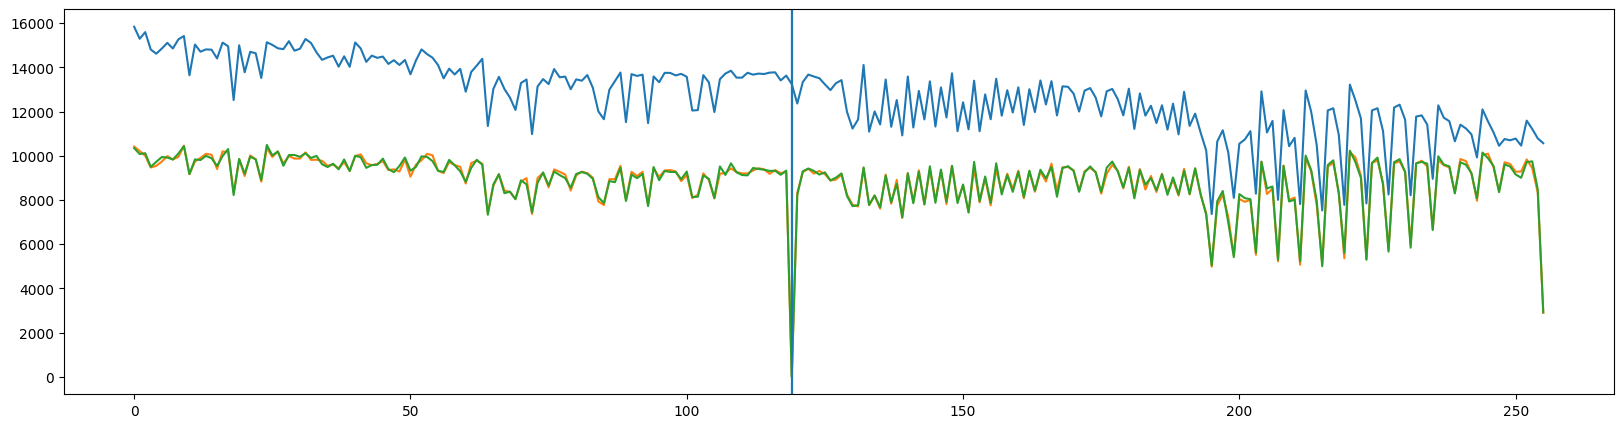

In [246]:
cor_filepath0 = r"D:\Acq_gui\20260118\Air_0mmps_75kv_4.0ma_cali_10mspf_sid610_sdd670cor.mat"
filter_files = ["Air","Sn","Ba","Ce","Pb"]
# cor_filepath6 = r"D:\Acq_gui\20260118\ykl1_10mmps_75kv_4.0ma_cali_10mspf_sid610_sdd670cor.mat"
# cor_filepath7 = r"D:\Acq_gui\20260118\ykl2_10mmps_75kv_4.0ma_cali_10mspf_sid610_sdd670cor.mat"
# cor_filepath8 = r"D:\Acq_gui\20260118\chicken_30mmps_75kv_4.0ma_cali_10mspf_sid610_sdd670cor.mat"

# cor_filepath1 = r"D:\Acq_gui\20260119\test_xianshuqi8_30mmps_75kv_4.0ma_cali_10mspf_sid610_sdd670cor.mat"
cor_filepath1 = r"D:\Acq_gui\20260119\imaging2\ykl1_10mmps_75kv_4.0ma_cali_10mspf_sid610_sdd830cor.mat"
cor_filepath2 = r"D:\Acq_gui\20260119\imaging2\chicken1_18mmps_75kv_4.0ma_cali_10mspf_sid710_sdd830cor.mat"
plt.figure(figsize=(20,5))
for f in [
    # cor_filepath0, cor_filepath1, 
        #   cor_filepath2, cor_filepath3,
          cor_filepath0, cor_filepath1, cor_filepath2]:
    cor_pos, cor_data = load_mat_from_file(f)
    print(cor_pos.shape, cor_data.shape)

    plt.plot(cor_data.sum(axis=-1)[100, :])
    # plt.ylim(10000,16000)
    cid =120
    nd = cor_data[:,cid,:].sum(axis=0)/cor_data[:,cid,:].sum(axis=0).mean()
    plt.axvline(x=119)
    # plt.plot(nd)

# plt.imshow(cor_data.sum(axis=-1),aspect="auto")

(150, 256, 101)


C:\Users\ranch\AppData\Local\Temp\ipykernel_18160\2412304663.py:3: RuntimeWarning: divide by zero encountered in divide
  norm_cor_data = cor_data.sum(axis=-1) * (np.mean(norm_data) / np.mean(norm_data, axis=(0,2)))
C:\Users\ranch\AppData\Local\Temp\ipykernel_18160\2412304663.py:3: RuntimeWarning: invalid value encountered in multiply
  norm_cor_data = cor_data.sum(axis=-1) * (np.mean(norm_data) / np.mean(norm_data, axis=(0,2)))


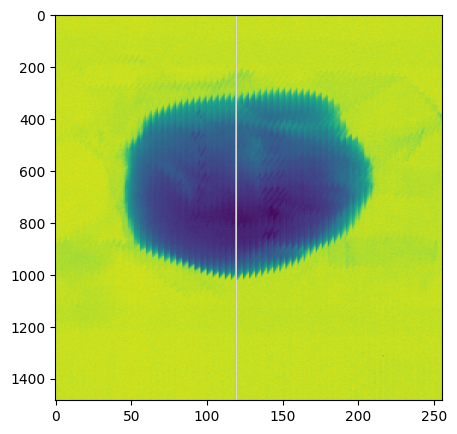

In [247]:
norm_data = cor_data[50:200]
print(norm_data.shape)
norm_cor_data = cor_data.sum(axis=-1) * (np.mean(norm_data) / np.mean(norm_data, axis=(0,2)))

fig = plt.figure(figsize=(5, 5))
# plt.imshow(norm_cor_data[0:1800,:,:].sum(axis=-1), aspect='auto')
plt.imshow(norm_cor_data[0:1800,:], aspect='auto')
# sag_filepath = r"C:\Users\vplus\Documents\Projects\Acq_gui\ScanTask_600_100mmps_80kv_10ma_cali_10mspf_sid1000_cor.mat"

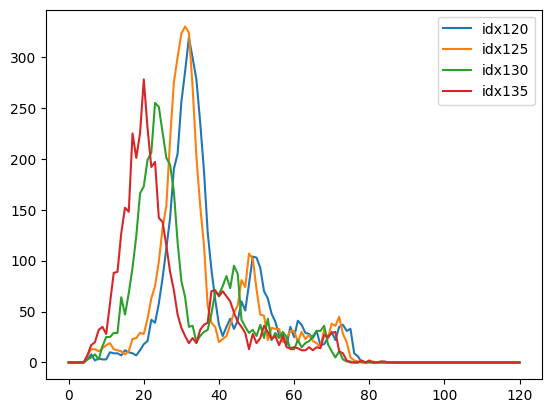

In [64]:
spectrum = cor_data.sum(axis=0)

spectrum2 = spectrum.T
spectrum2[:5, :] = 0

for i in range(120, 140, 5):
    _ = plt.plot(spectrum2[:, i], label=f"idx{i}")

plt.legend()

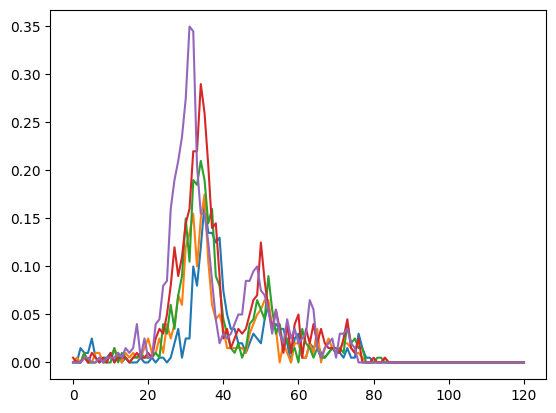

In [65]:
for cid in range(0,50,10):
    plt.plot(cor_data[0:200,cid,:].mean(axis=0))

In [6]:
import os
from tqdm import tqdm

base_dir = r"D:\Acq_gui\bei_acq"
all_pixel_arr = []
for filename in tqdm(os.listdir(base_dir)[:2000]):
    pos_arr, pix_arr = load_mat_from_file(os.path.join(base_dir, filename))
    all_pixel_arr.append(pix_arr)


100%|██████████| 2000/2000 [00:11<00:00, 179.23it/s]


In [7]:

all_pixel_arr2 = np.array(all_pixel_arr)

print(all_pixel_arr2.shape)

(2000, 50, 256, 101)


In [8]:

all_pixel_arr3 = np.vstack(all_pixel_arr)
print(all_pixel_arr3.shape)

(100000, 256, 101)


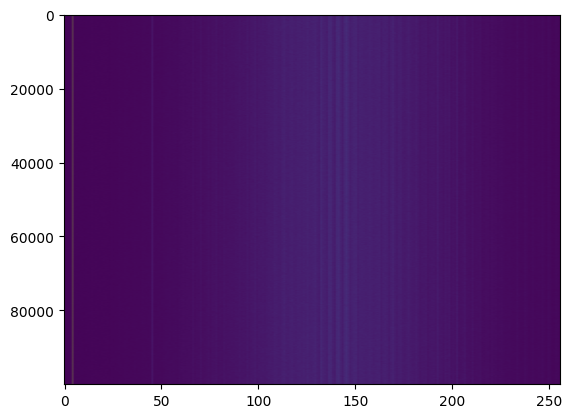

In [9]:

plt.imshow(all_pixel_arr3.sum(axis=2), aspect='auto')

In [10]:
tmp = all_pixel_arr3.sum(axis=0)[:, 10:]

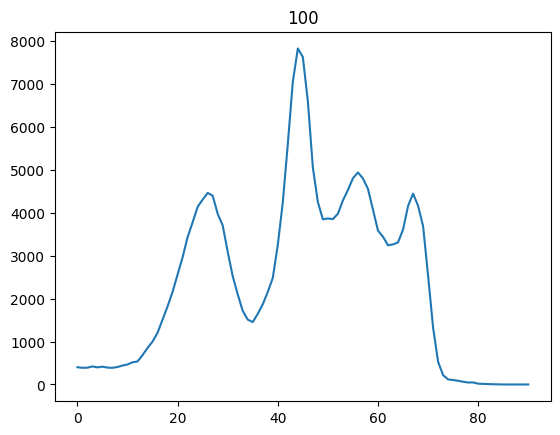

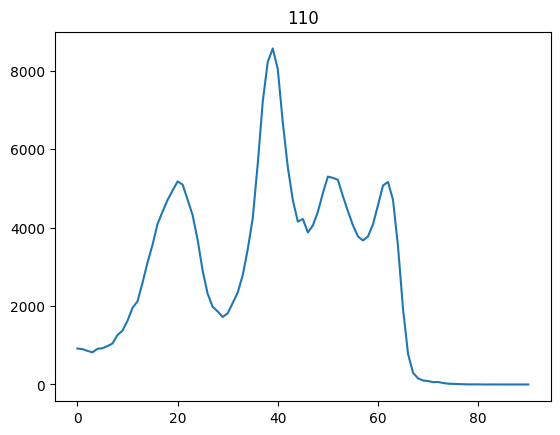

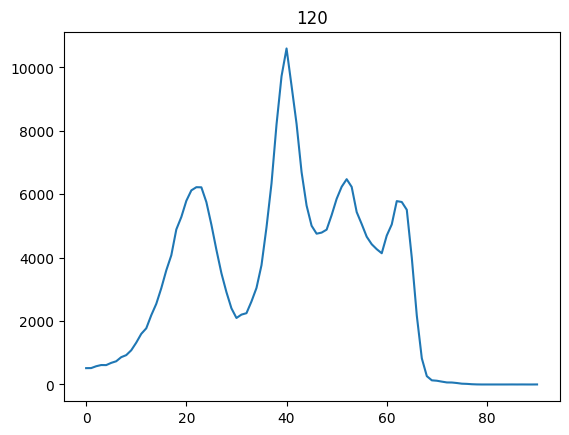

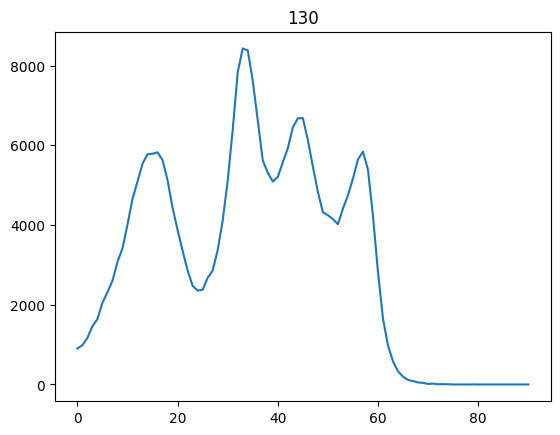

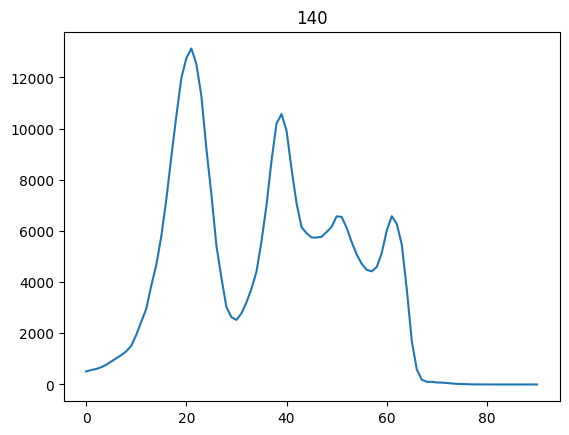

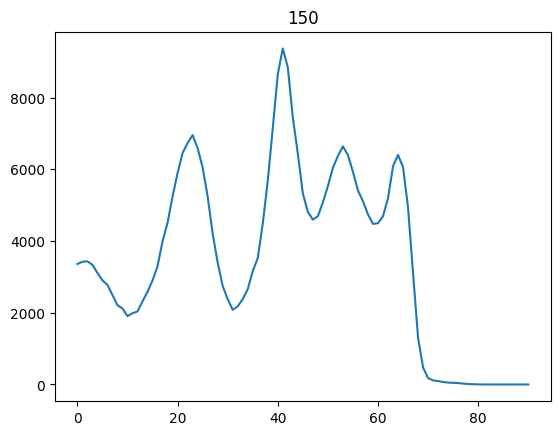

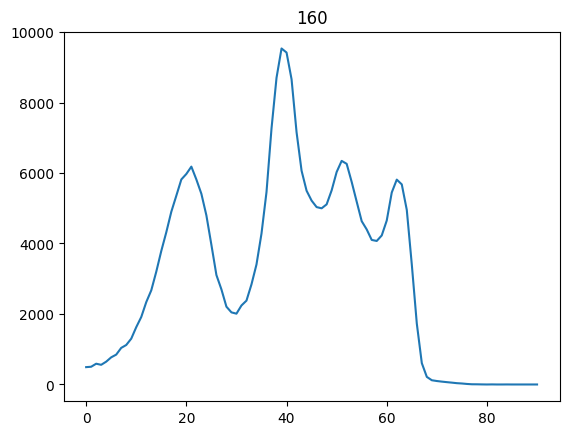

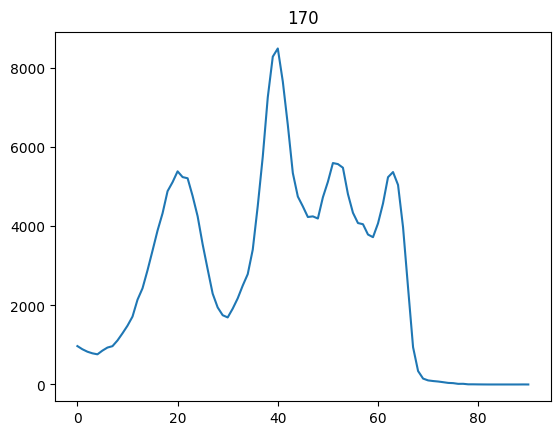

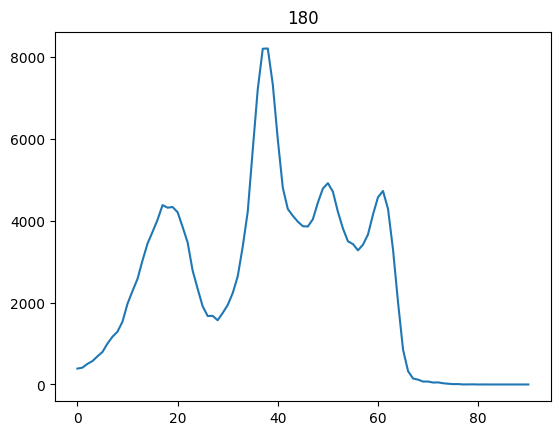

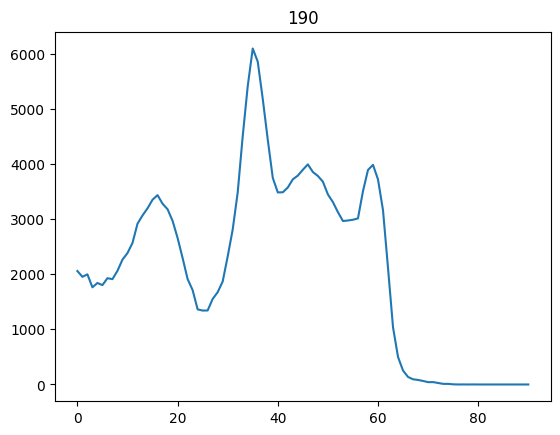

In [11]:
for i in range(100, 200, 10):
    _ = plt.plot(tmp[i].T)
    plt.title(i)
    plt.show()